Trial 3 Complete [00h 03m 55s]
val_loss: 0.011955780908465385

Best val_loss So Far: 0.008826726116240025
Total elapsed time: 00h 14m 40s

Optimal Hyperparameters Found:
- Convolutional Filters: 32
- Learning Rate: 0.01

Training final model with best hyperparameters...
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 132s 278ms/step - loss: 0.0165 - val_loss: 0.0102
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 279ms/step - loss: 0.0095 - val_loss: 0.0088
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 132s 281ms/step - loss: 0.0086 - val_loss: 0.0086
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 130s 277ms/step - loss: 0.0081 - val_loss: 0.0079
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 131s 279ms/step - loss: 0.0078 - val_loss: 0.0077
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 277ms/step - loss: 0.0076 - val_loss: 0.0076
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 276ms/step - loss: 0.0075 - val_loss: 0.0074
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 277ms/step - loss: 0.0074 - val_loss: 0.0074
Epoch 9/1

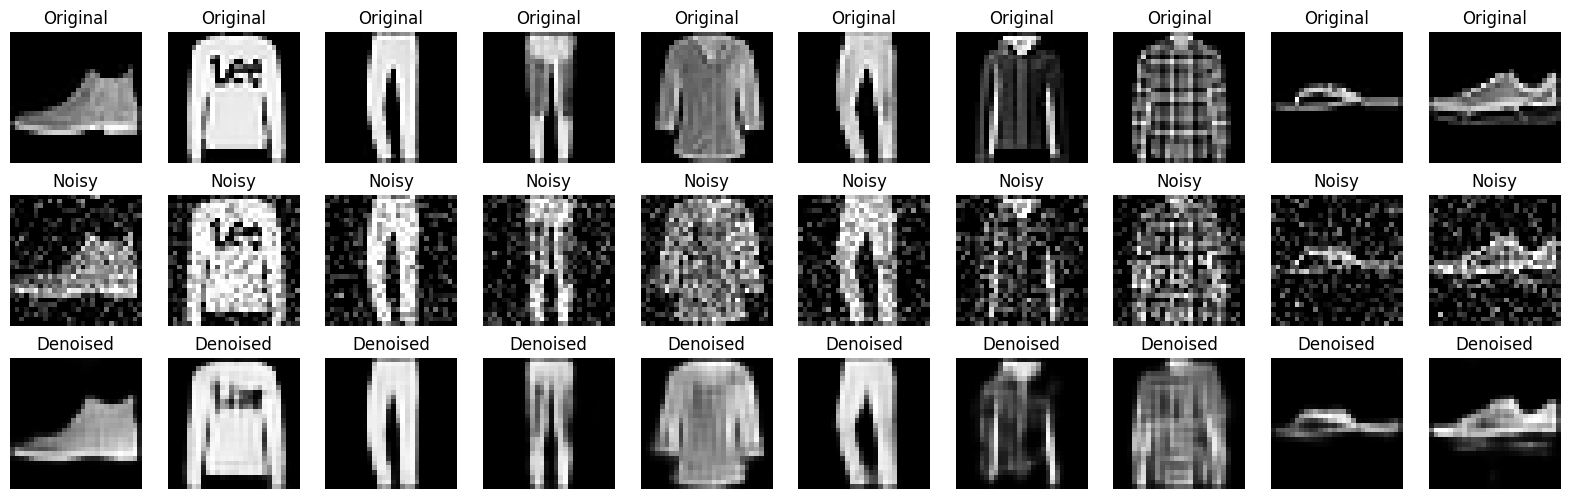

In [1]:
!pip install keras-tuner -q

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
import keras_tuner as kt

# ==========================================
# 1. Load and Prepare the Dataset
# ==========================================
(x_train, _), (x_test, _) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape to include the channel dimension (28, 28, 1)
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# Add synthetic Gaussian noise
noise_factor = 0.2
x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape)
x_test_noisy = x_test + noise_factor * tf.random.normal(shape=x_test.shape)

# Clip values to stay within valid image bounds [0, 1]
x_train_noisy = tf.clip_by_value(x_train_noisy, clip_value_min=0., clip_value_max=1.)
x_test_noisy = tf.clip_by_value(x_test_noisy, clip_value_min=0., clip_value_max=1.)

# ==========================================
# 2. Define Model Builder for Hyperparameter Tuning
# ==========================================
def build_model(hp):
    model = models.Sequential()

    # Tune the number of filters in the first convolutional layer
    hp_filters = hp.Int('filters', min_value=16, max_value=64, step=16)

    # Encoder
    model.add(layers.Input(shape=(28, 28, 1)))
    model.add(layers.Conv2D(hp_filters, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2), padding='same'))
    model.add(layers.Conv2D(hp_filters, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2), padding='same'))

    # Decoder
    model.add(layers.Conv2D(hp_filters, (3, 3), activation='relu', padding='same'))
    model.add(layers.UpSampling2D((2, 2)))
    model.add(layers.Conv2D(hp_filters, (3, 3), activation='relu', padding='same'))
    model.add(layers.UpSampling2D((2, 2)))
    model.add(layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same'))

    # Tune the learning rate
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='mse')
    return model

# ==========================================
# 3. Execute Hyperparameter Tuning
# ==========================================
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=3, # Keep low for quick Colab execution
    executions_per_trial=1,
    directory='autoencoder_tuning',
    project_name='fashion_mnist_denoising'
)

print("Starting Hyperparameter Tuning...")
tuner.search(x_train_noisy, x_train,
             epochs=3,
             validation_data=(x_test_noisy, x_test),
             batch_size=128)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"""
Optimal Hyperparameters Found:
- Convolutional Filters: {best_hps.get('filters')}
- Learning Rate: {best_hps.get('learning_rate')}
""")

# ==========================================
# 4. Train the Final Model
# ==========================================
print("Training final model with best hyperparameters...")
model = tuner.hypermodel.build(best_hps)
history = model.fit(x_train_noisy, x_train,
                    epochs=10,
                    batch_size=128,
                    validation_data=(x_test_noisy, x_test))

# ==========================================
# 5. Visualizing the Output
# ==========================================
decoded_imgs = model.predict(x_test_noisy)

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Display Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(tf.squeeze(x_test[i]), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Display Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(tf.squeeze(x_test_noisy[i]), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Display Reconstruction
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(tf.squeeze(decoded_imgs[i]), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')
plt.show()

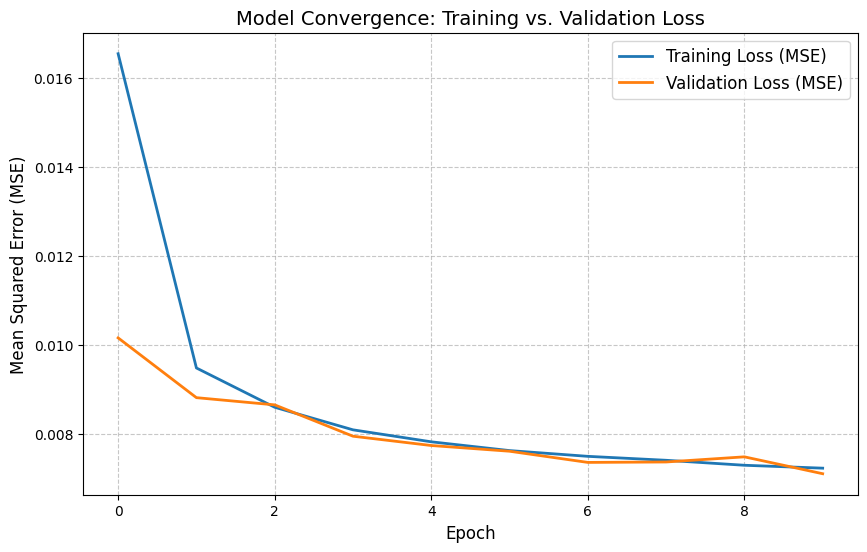

/tmp/ipykernel_2807/1430132157.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ssim_noisy.numpy(), ssim_denoised.numpy()],


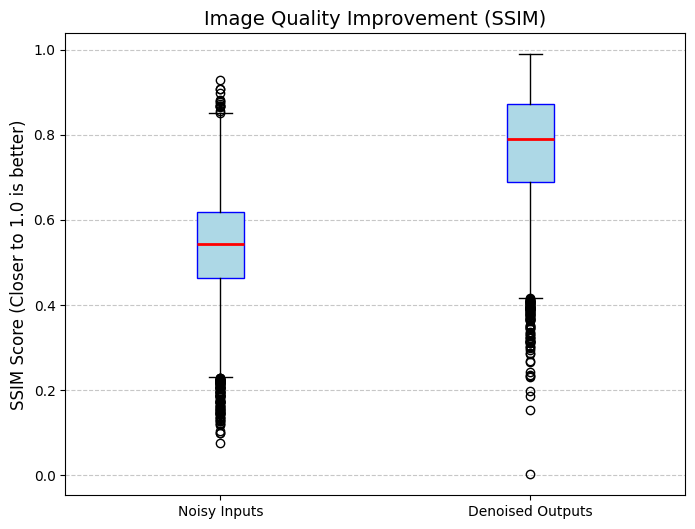

Average SSIM (Noisy Input): 0.5381
Average SSIM (Denoised Output): 0.7733


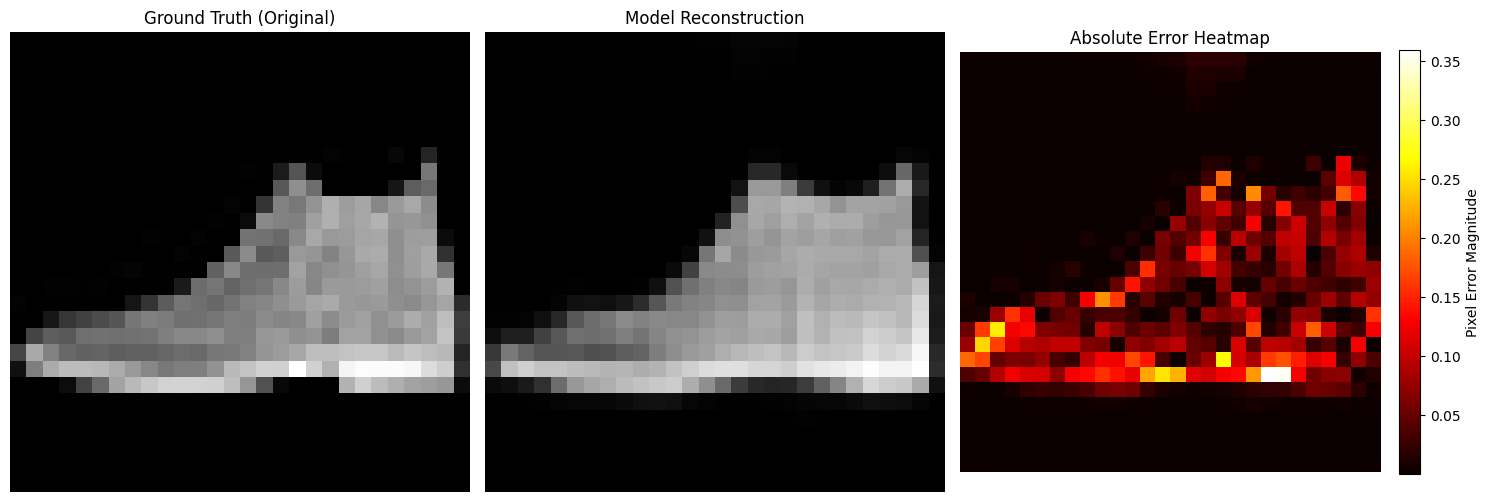

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# ==========================================
# Chart 1: Training vs. Validation Loss Curve
# ==========================================
# This shows if your model is learning effectively or overfitting.
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss (MSE)', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', linewidth=2)
plt.title('Model Convergence: Training vs. Validation Loss', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# ==========================================
# Chart 2: SSIM (Structural Similarity Index) Boxplot
# ==========================================
# SSIM measures perceived change in structural information (1.0 is a perfect match).
# This compares the quality of the noisy images against the restored images.

# Calculate SSIM across the entire test set
ssim_noisy = tf.image.ssim(x_test, x_test_noisy, max_val=1.0)
ssim_denoised = tf.image.ssim(x_test, decoded_imgs, max_val=1.0)

plt.figure(figsize=(8, 6))
plt.boxplot([ssim_noisy.numpy(), ssim_denoised.numpy()],
            labels=['Noisy Inputs', 'Denoised Outputs'],
            patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='red', linewidth=2))
plt.title('Image Quality Improvement (SSIM)', fontsize=14)
plt.ylabel('SSIM Score (Closer to 1.0 is better)', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Average SSIM (Noisy Input): {np.mean(ssim_noisy):.4f}")
print(f"Average SSIM (Denoised Output): {np.mean(ssim_denoised):.4f}")

# ==========================================
# Chart 3: Pixel-wise Absolute Error Heatmap
# ==========================================
# This visualizes exactly *where* the model struggles to reconstruct the image.
index_to_visualize = 0 # Change this to see different images in the test set

orig_img = tf.squeeze(x_test[index_to_visualize])
denoised_img = tf.squeeze(decoded_imgs[index_to_visualize])
# Calculate absolute difference between original and denoised
error_map = tf.abs(orig_img - denoised_img)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original
axes[0].imshow(orig_img, cmap='gray')
axes[0].set_title('Ground Truth (Original)', fontsize=12)
axes[0].axis('off')

# Denoised
axes[1].imshow(denoised_img, cmap='gray')
axes[1].set_title('Model Reconstruction', fontsize=12)
axes[1].axis('off')

# Error Heatmap
im = axes[2].imshow(error_map, cmap='hot')
axes[2].set_title('Absolute Error Heatmap', fontsize=12)
axes[2].axis('off')
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04, label='Pixel Error Magnitude')

plt.tight_layout()
plt.show()